In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [4]:
df = pd.read_excel("data/2022 Annual Client Survey Data.xlsx")
df.head()

,"Overall, please rate your satisfaction with the services you received from the Dempsey Center.","As a result of the services I received at the Dempsey Center, I feel that the following areas of my life were positively impacted (select all that apply).",Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,"Overall, did/does the Dempsey Center make your life better as it relates to your cancer impact?",Which Dempsey Center Services have you used in 2022? (Select all that apply.),Unnamed: 8,Unnamed: 9,...,Optional: How would you describe your current sexual orientation/identity?,Unnamed: 63,Optional: Do you live with any of the following disabilities? (Please select all that apply.),Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,"Optional: If you'd like to provide any additional feedback for the Dempsey Center that was not addressed in this survey, please provide your name and contact information (phone or email), and a staff member at the Dempsey Center will reach out to you."
0,Response,None of the above,"Physical Well-Being (e.g., addressing concerns...","Social/Family Well-Being (e.g., addressing con...","Emotional Well-Being (e.g., addressing concern...","Functional Well-Being (e.g., addressing concer...",Response,Acupuncture,Adult Counseling - Individual,Adult Counseling - Support Groups,...,Response,Prefer to self-describe (please specify):,Hearing Difficulty (deaf or serious difficulty...,"Vision Difficulty (blind, or having serious di...","Cognitive Difficulty (remembering, concentrati...",Ambulatory Difficulty (walking or climbing sta...,Self-Care Difficulty (bathing or dressing),Independent Living Difficulty (completing erra...,Prefer to self-describe (please specify):,Open-Ended Response
1,Very Satisfied,NaN,NaN,NaN,NaN,"Functional Well-Being (e.g., addressing concer...",Yes,Acupuncture,NaN,NaN,...,Heterosexual or Straight,NaN,NaN,NaN,NaN,Ambulatory Difficulty (walking or climbing sta...,NaN,NaN,NaN,NaN
2,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...",NaN,"Emotional Well-Being (e.g., addressing concern...",NaN,Yes,NaN,NaN,NaN,...,Heterosexual or Straight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...",NaN,NaN,NaN,Yes,Acupuncture,NaN,NaN,...,Heterosexual or Straight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...",NaN,"Emotional Well-Being (e.g., addressing concern...",NaN,Yes,Acupuncture,NaN,NaN,...,Heterosexual or Straight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df = df.iloc[1:].reset_index(drop=True)
df.head()

,"Overall, please rate your satisfaction with the services you received from the Dempsey Center.","As a result of the services I received at the Dempsey Center, I feel that the following areas of my life were positively impacted (select all that apply).",Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,"Overall, did/does the Dempsey Center make your life better as it relates to your cancer impact?",Which Dempsey Center Services have you used in 2022? (Select all that apply.),Unnamed: 8,Unnamed: 9,...,Optional: How would you describe your current sexual orientation/identity?,Unnamed: 63,Optional: Do you live with any of the following disabilities? (Please select all that apply.),Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,"Optional: If you'd like to provide any additional feedback for the Dempsey Center that was not addressed in this survey, please provide your name and contact information (phone or email), and a staff member at the Dempsey Center will reach out to you."
0,Very Satisfied,NaN,NaN,NaN,NaN,"Functional Well-Being (e.g., addressing concer...",Yes,Acupuncture,NaN,NaN,...,Heterosexual or Straight,NaN,NaN,NaN,NaN,Ambulatory Difficulty (walking or climbing sta...,NaN,NaN,NaN,NaN
1,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...",NaN,"Emotional Well-Being (e.g., addressing concern...",NaN,Yes,NaN,NaN,NaN,...,Heterosexual or Straight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...",NaN,NaN,NaN,Yes,Acupuncture,NaN,NaN,...,Heterosexual or Straight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...",NaN,"Emotional Well-Being (e.g., addressing concern...",NaN,Yes,Acupuncture,NaN,NaN,...,Heterosexual or Straight,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...","Social/Family Well-Being (e.g., addressing con...","Emotional Well-Being (e.g., addressing concern...","Functional Well-Being (e.g., addressing concer...",Yes,NaN,NaN,NaN,...,Heterosexual or Straight,NaN,NaN,NaN,NaN,Ambulatory Difficulty (walking or climbing sta...,NaN,NaN,NaN,NaN


In [6]:
for col in df.columns:
    if "satisfaction" in col.lower():
        print(col)

Overall, please rate your satisfaction with the services you received from the Dempsey Center.


In [7]:
satisfaction_col = "Overall, please rate your satisfaction with the services you received from the Dempsey Center."

In [8]:
df[satisfaction_col].value_counts()

Overall, please rate your satisfaction with the services you received from the Dempsey Center.
Very Satisfied                       200
Satisfied                             45
Very Unsatisfied                      12
Unsatisfied                            7
Neither Satisfied nor Unsatisfied      5
Name: count, dtype: int64

In [9]:
very_satisfied_pct = (df[satisfaction_col] == "Very Satisfied").mean() * 100
very_satisfied_pct

np.float64(74.34944237918215)

In [10]:
sat_or_very_pct = df[satisfaction_col].isin(["Satisfied", "Very Satisfied"]).mean() * 100
sat_or_very_pct

np.float64(91.07806691449815)

In [12]:
files = {
    2022: "2022 Annual Client Survey Data.xlsx",
    2023: "2023 Annual Client Survey Data.xlsx",
    2024: "2024 Annual Client Survey.xlsx",
    2025: "Dempsey Center 2025 Annual Client Survey.xlsx",
}

In [13]:
summary = []

for year, file in files.items():
    df = pd.read_excel(f"data/{file}")
    
    # 删除第一行垃圾
    df = df.iloc[1:].reset_index(drop=True)
    
    # 找 satisfaction 列
    for col in df.columns:
        if "satisfaction" in col.lower():
            satisfaction_col = col
            break
    
    # 计算指标
    n = len(df)
    very_sat = (df[satisfaction_col] == "Very Satisfied").mean() * 100
    sat_or_very = df[satisfaction_col].isin(["Satisfied", "Very Satisfied"]).mean() * 100
    
    summary.append({
        "year": year,
        "responses": n,
        "very_satisfied_pct": round(very_sat, 1),
        "sat_or_very_pct": round(sat_or_very, 1)
    })

summary_df = pd.DataFrame(summary)
summary_df

,year,responses,very_satisfied_pct,sat_or_very_pct
0,2022,269,74.3,91.1
1,2023,298,74.8,85.9
2,2024,293,76.8,89.8
3,2025,319,75.5,90.3


In [19]:
better_col = None

for col in df.columns:
    if "make your life better" in col.lower() and "in what ways" not in col.lower():
        better_col = col
        break

In [20]:
(df[col] == "Yes").mean() * 100

np.float64(95.29780564263322)

In [22]:
recommend_col = None

for col in df.columns:
    if "recommend" in col.lower():
        recommend_col = col
        print(col)
        break

df[recommend_col] = pd.to_numeric(df[recommend_col], errors="coerce")
df[recommend_col].mean()

9. Based on your experience as a client with the Dempsey Center, how likely are you to recommend the services the Dempsey Center provides to a friend, family member, or colleague who is impacted by cancer?


np.float64(9.616438356164384)

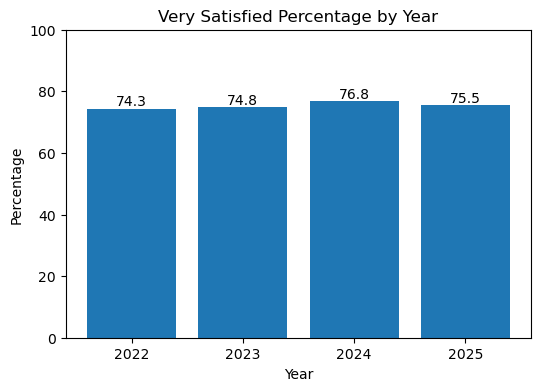

In [25]:
plt.figure(figsize=(6,4))

plt.bar(summary_df["year"].astype(str), summary_df["very_satisfied_pct"])

# 👇 就放在这里（关键）
for i, v in enumerate(summary_df["very_satisfied_pct"]):
    plt.text(i, v + 1, str(v), ha='center')

plt.title("Very Satisfied Percentage by Year")
plt.xlabel("Year")
plt.ylabel("Percentage")

plt.ylim(0, 100)

plt.show()

In [26]:
# 你需要先把这个加进 summary_df（如果还没加）

better_summary = []

for year, file in files.items():
    df = pd.read_excel(f"data/{file}")
    df = df.iloc[1:].reset_index(drop=True)
    
    better_col = None
    for col in df.columns:
        if "make your life better" in col.lower() and "in what ways" not in col.lower():
            better_col = col
            break
    
    pct = (df[better_col] == "Yes").mean() * 100
    
    better_summary.append(pct)

summary_df["made_life_better_pct"] = better_summary
summary_df

,year,responses,very_satisfied_pct,sat_or_very_pct,made_life_better_pct
0,2022,269,74.3,91.1,95.167286
1,2023,298,74.8,85.9,95.637584
2,2024,293,76.8,89.8,95.904437
3,2025,319,75.5,90.3,95.297806


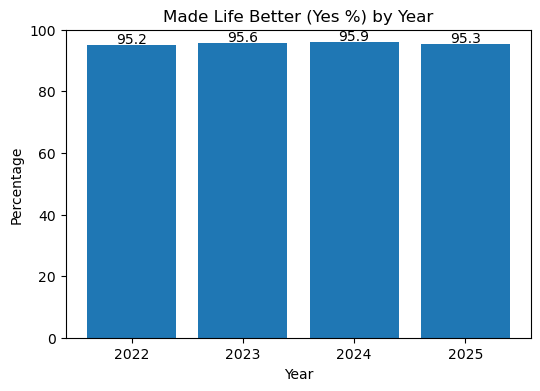

In [28]:
plt.figure(figsize=(6,4))

plt.bar(summary_df["year"].astype(str), summary_df["made_life_better_pct"])

for i, v in enumerate(summary_df["made_life_better_pct"]):
    plt.text(i, v + 0.5, str(round(v,1)), ha='center')
plt.title("Made Life Better (Yes %) by Year")
plt.xlabel("Year")
plt.ylabel("Percentage")

plt.ylim(0, 100)

plt.savefig("life_better_bar.png")
plt.show()

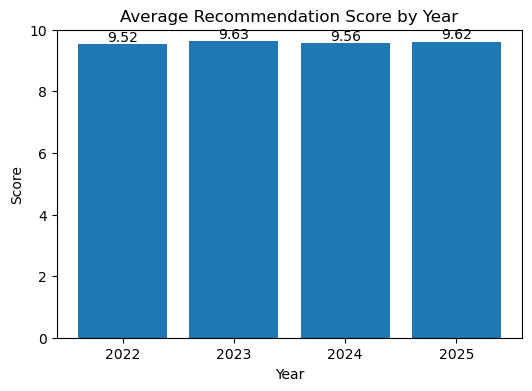

In [31]:
plt.figure(figsize=(6,4))

plt.bar(summary_df["year"].astype(str), summary_df["avg_recommend_score"])

# 标数字
for i, v in enumerate(summary_df["avg_recommend_score"]):
    plt.text(i, v + 0.1, str(round(v,2)), ha='center')

plt.title("Average Recommendation Score by Year")
plt.xlabel("Year")
plt.ylabel("Score")

plt.ylim(0, 10)

plt.savefig("recommendation_bar.png")
plt.show()

In [30]:
recommend_summary = []

for year, file in files.items():
    df = pd.read_excel(f"data/{file}")
    df = df.iloc[1:].reset_index(drop=True)
    
    recommend_col = None
    for col in df.columns:
        if "recommend" in col.lower():
            recommend_col = col
            break
    
    df[recommend_col] = pd.to_numeric(df[recommend_col], errors="coerce")
    avg_score = df[recommend_col].mean()
    
    recommend_summary.append(avg_score)

summary_df["avg_recommend_score"] = recommend_summary

In [32]:
summary_df.to_csv("summary_table.csv", index=False)

In [33]:
all_clean = pd.concat(cleaned_data.values(), ignore_index=True)
all_clean.to_csv("clean_all_years.csv", index=False)

NameError: name 'cleaned_data' is not defined

In [34]:
all_clean_list = []

for year, file in files.items():
    df = pd.read_excel(f"data/{file}")
    df = df.iloc[1:].reset_index(drop=True)
    
    df["year"] = year  # 加一列年份（很重要）
    
    all_clean_list.append(df)

all_clean = pd.concat(all_clean_list, ignore_index=True)

all_clean.to_csv("clean_all_years.csv", index=False)

all_clean.head()

,"Overall, please rate your satisfaction with the services you received from the Dempsey Center.","As a result of the services I received at the Dempsey Center, I feel that the following areas of my life were positively impacted (select all that apply).",Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,"Overall, did/does the Dempsey Center make your life better as it relates to your cancer impact?",Which Dempsey Center Services have you used in 2022? (Select all that apply.),Unnamed: 8,Unnamed: 9,...,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,23. Which of the following best describes the type of health insurance coverage you currently have (select one)?,Unnamed: 102,24. What is the last year of schooling that you have completed?,Optional: Please share any other feedback regarding your experience with Dempsey Center services in 2025 that would be helpful for us to know.
0,Very Satisfied,NaN,NaN,NaN,NaN,"Functional Well-Being (e.g., addressing concer...",Yes,Acupuncture,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...",NaN,"Emotional Well-Being (e.g., addressing concern...",NaN,Yes,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...",NaN,NaN,NaN,Yes,Acupuncture,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...",NaN,"Emotional Well-Being (e.g., addressing concern...",NaN,Yes,Acupuncture,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Very Satisfied,NaN,"Physical Well-Being (e.g., addressing concerns...","Social/Family Well-Being (e.g., addressing con...","Emotional Well-Being (e.g., addressing concern...","Functional Well-Being (e.g., addressing concer...",Yes,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
all_clean["year"].value_counts()

year
2025    319
2023    298
2024    293
2022    269
Name: count, dtype: int64

In [36]:
summary_df = summary_df.round({
    "very_satisfied_pct": 1,
    "sat_or_very_pct": 1,
    "made_life_better_pct": 1,
    "avg_recommend_score": 2
})

In [37]:
summary_df.to_csv("summary_table.csv", index=False)

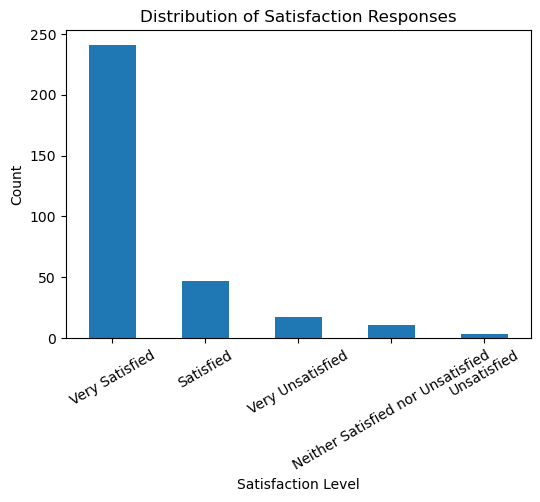

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df[satisfaction_col].value_counts().plot(kind='bar')

plt.title("Distribution of Satisfaction Responses")
plt.xlabel("Satisfaction Level")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()